# STEP 3 · 基线错配与三类情景
在开头选择 `CITY`、`CITY_CONFIG` 和 `MODE`。本 notebook 与 `run_all.py` 使用同一套多城市逻辑：S1 只增、S2 只减、S3 等量调配，每个情景都有一张降幅曲线和两张口径地图（空间置换、时间排队）。


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cso, style
style.set_nature()

CITY = 'guangzhou'      # 城市配置键；全国城市可改成 'shenzhen' 等
CITY_CONFIG = ''        # 可选：外部 city_configs.json 路径，例如 r'../city_configs.json'
MODE = 'truncated'      # 'truncated' 或 'comprehensive'
NOTEBOOK_SMOKE = False  # True 时减少抽样和候选规模，先快速跑通链路

cso.configure_city(CITY, CITY_CONFIG or None)
DRAWS = 5 if NOTEBOOK_SMOKE else cso.N_ENSEMBLE
print(f'当前城市：{cso.CITY_NAME} ({cso.CITY}) | 口径：{MODE} | 抽样次数：{DRAWS}')


当前城市：广州 (guangzhou) | 口径：truncated | 抽样次数：40


In [2]:
st = cso.load_stations(MODE)
slon, slat = st['lon'].values, st['lat'].values
fast, slow = st['fast'].values, st['slow'].values
sid = st['sid'].values
nF = len(slon)
D = cso.demand_surface(draws=DRAWS)
lc, ac, w = D['lon_c'], D['lat_c'], D['w']
c = cso.dist_matrix(lc, ac, slon, slat)
s_fix = cso._disp_scale(w, fast, slow)
counts = cso.add_counts(nF)
if NOTEBOOK_SMOKE:
    counts = (max(1, min(counts[0], 3)),)
labels = [f'{int(f*100)}%' for f in cso.ADD_FRACS][:len(counts)]
n_max = max(counts)
cand = np.argsort(w)[::-1][:min(cso.CAND_CAP, int((w > 0).sum()))]
pool = min(len(cand), max(20 if NOTEBOOK_SMOKE else cso.CAP_POOL, int(n_max)))
print(f'站点 {nF} 个 | 需求格 {D["n_cells"]} 个 | 最大变化站点数 {n_max} | 候选池 {pool}')


站点 873 个 | 需求格 3336 个 | 最大变化站点数 88 | 候选池 88


## 3.1 基线三指标 + 失配分解
`M_old` 是零拥挤参照；`M_disp` 是空间置换口径，单位是需求·km；`M_queue` 是时间排队口径，单位是需求·min。两个口径单位不同，跨城市比较时优先看相对改善百分比和每次低电量事件平均负担。


M_old(零拥挤参照) = 14922 需求·km
空间置换 = 798776 需求·km，折分钟 1597553 需求·min
时间排队 = 716578 需求·min
每次低电量事件：空间置换 177.94 km/次，时间排队 159.63 min/次


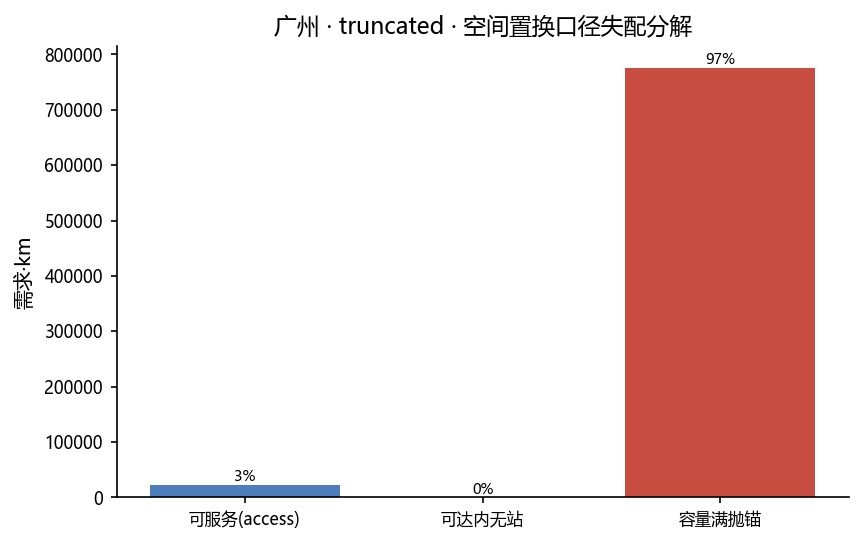

In [3]:
b = cso.both_indices(w, c, fast, slow)
print(f'M_old(零拥挤参照) = {b["M_old_km"]:.0f} 需求·km')
print(f'空间置换 = {b["M_disp_km"]:.0f} 需求·km，折分钟 {b["M_disp_min"]:.0f} 需求·min')
print(f'时间排队 = {b["M_queue_min"]:.0f} 需求·min')
print(f'每次低电量事件：空间置换 {b["M_disp_km"]/max(w.sum(),1e-12):.2f} km/次，时间排队 {b["M_queue_min"]/max(w.sum(),1e-12):.2f} min/次')

dd = b['disp']
lab = ['可服务(access)', '可达内无站', '容量满抛锚']
val = [dd['M_access'], dd['M_dead_range'], dd['M_dead_cap']]
fig, ax = plt.subplots(figsize=style.mm(100, 62))
ax.bar(lab, val, color=[style.C['blue'], style.C['orange'], style.C['red']], alpha=.90)
for i, vv in enumerate(val):
    ax.text(i, vv, f'{vv/max(sum(val),1e-12)*100:.0f}%', ha='center', va='bottom', fontsize=7)
ax.set_ylabel('需求·km')
ax.set_title(f'{cso.CITY_NAME} · {MODE} · 空间置换口径失配分解')
plt.show()


## 3.2 运行 S1/S2/S3
这里会直接调用 `cso.greedy_add / greedy_remove / swap`。`swap` 已保证关闭数和新增数相等；如果候选格不足，会在输出里提醒。


In [4]:
def pad_history(values, target_len):
    v = list(map(float, values))
    if len(v) < target_len:
        v.extend([v[-1]] * (target_len - len(v)))
    return v[:target_len]

def demand_norm(w):
    m = w > 0
    vmax = float(np.percentile(w[m], 98)) if np.any(m) else 1.0
    return mcolors.PowerNorm(gamma=0.72, vmin=0.0, vmax=max(vmax, 1e-9))

def plot_curve(title, histories):
    fig, ax = plt.subplots(figsize=style.mm(150, 88))
    for lens, M in histories.items():
        M = np.asarray(M, float)
        y = M / M[0]
        col = style.C['blue'] if lens == 'disp' else style.C['red']
        name = {'disp': '空间置换', 'queue': '时间排队'}[lens]
        ax.plot(np.arange(len(M)), y, '-', lw=2, color=col, label=name)
        xs = [int(n) for n in counts if int(n) < len(M)]
        ax.scatter(xs, [y[x] for x in xs], color=col, s=26, zorder=5)
        for lab, x in zip(labels, xs):
            ax.annotate(lab, (x, y[x]), textcoords='offset points', xytext=(0, 6), ha='center', fontsize=7, color=col)
    ax.axhline(1, color=style.C['gray'], ls='--', lw=.8)
    ax.set_xticks([0] + [int(n) for n in counts])
    ax.set_xticklabels(['0'] + [f'{int(n)}\n({lab})' for n, lab in zip(counts, labels)])
    ax.set_xlabel('变化站点数 N（括号为现有站点比例）')
    ax.set_ylabel('相对错配指数 M / M_base')
    ax.set_title(title)
    ax.legend()
    plt.show()

def plot_map(title, add_idx=None, remove_idx=None):
    add_idx = np.asarray(add_idx if add_idx is not None else [], dtype=int)
    remove_idx = np.asarray(remove_idx if remove_idx is not None else [], dtype=int)
    fig, ax = plt.subplots(figsize=style.mm(145, 145))
    style.draw_admin(ax, cache_dir=cso.DATA, adcode=cso.CITY_ADMIN_ADCODE, color='#7E8795', lw=.7)
    m = w > 0
    sc = ax.scatter(lc[m], ac[m], s=8, c=w[m], cmap=style.SEQ, norm=demand_norm(w), alpha=.82, linewidths=0, zorder=1)
    ax.scatter(slon, slat, s=2.2, c=style.C['gray'], marker='.', alpha=.35, zorder=2, label='现有站')
    if len(remove_idx):
        ax.scatter(slon[remove_idx], slat[remove_idx], s=28, c=style.C['red'], marker='x', lw=1.0, alpha=.95, zorder=4, label='关闭')
    if len(add_idx):
        ax.scatter(lc[add_idx], ac[add_idx], s=92, c=style.C['green'], marker='*', edgecolor='white', lw=.6, zorder=5, label='新增')
    fig.colorbar(sc, ax=ax, fraction=.04, pad=.02, label='期望低电量需求 (次/天/格)')
    ax.legend(loc='lower right')
    ax.set_title(title)
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('经度')
    ax.set_ylabel('纬度')
    plt.show()


In [5]:
results = {'s1': {}, 's2': {}, 's3': {}}
target_len = int(n_max) + 1
for lens in ['disp', 'queue']:
    name = {'disp': '空间置换', 'queue': '时间排队'}[lens]
    print(f'运行 {name}：S1/S2/S3')
    r1 = cso.greedy_add(w, c, fast, slow, lc[cand], ac[cand], lc, ac, n_max,
                        lens=lens, pool_n=pool, s=s_fix, force_n=True,
                        desc=f'S1 只增[{name}]')
    r2 = cso.greedy_remove(w, c, fast, slow, n_max, lens=lens, s=s_fix)
    r3 = cso.swap(w, c, fast, slow, lc[cand], ac[cand], lc, ac, n_max,
                  lens=lens, pool_n=pool, s=s_fix)
    results['s1'][lens] = r1
    results['s2'][lens] = r2
    results['s3'][lens] = r3
    print(f'  S3 关闭 {len(r3["removed"])} 个，新增 {len(r3["added"])} 个')


运行 空间置换：S1/S2/S3


S1 只增[空间置换]:   0%|          | 0/88 [00:00<?, ?it/s]

S2 删站[disp]:   0%|          | 0/88 [00:00<?, ?it/s]

S1 加站[disp]:   0%|          | 0/88 [00:00<?, ?it/s]

S2 删站[disp]:   0%|          | 0/88 [00:00<?, ?it/s]

...

S1 只增[时间排队]:   0%|          | 0/88 [00:00<?, ?it/s]

S2 删站[queue]:   0%|          | 0/88 [00:00<?, ?it/s]

S1 加站[queue]:   0%|          | 0/88 [00:00<?, ?it/s]

S2 删站[queue]:   0%|          | 0/88 [00:00<?, ?it/s]

  S3 关闭 88 个，新增 88 个


## 3.3 三类情景降幅曲线
纵轴 `M/M_base` 适合跨城市比较“相对改善幅度”；如果要比较城市本身的压力大小，还要看 `M/低电量事件数`，因为大城市需求事件更多，绝对 M 天然更大。


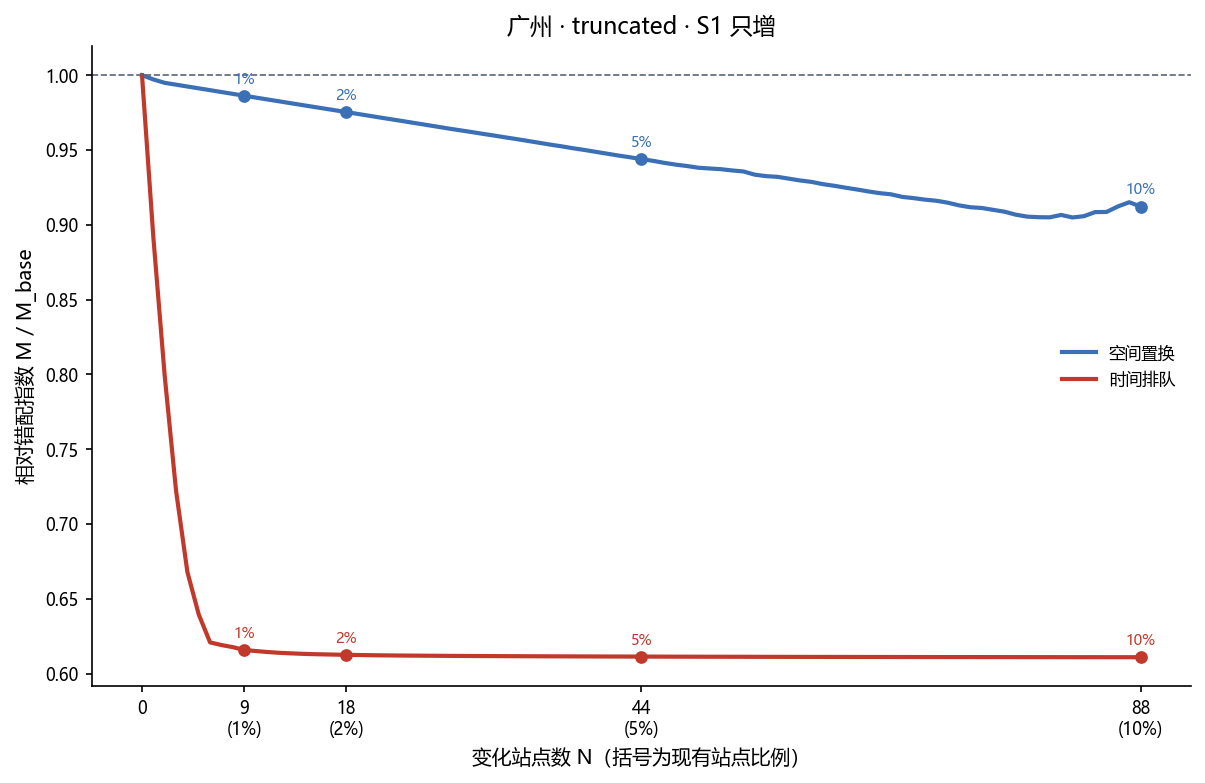

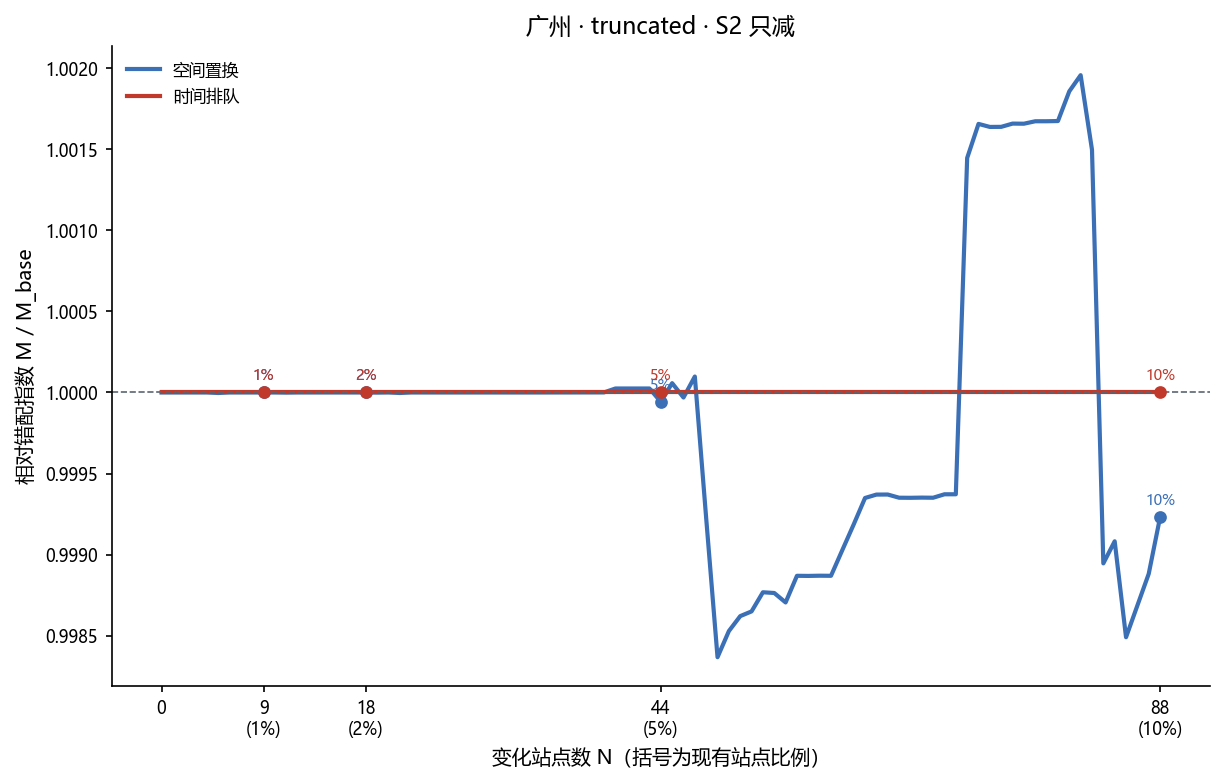

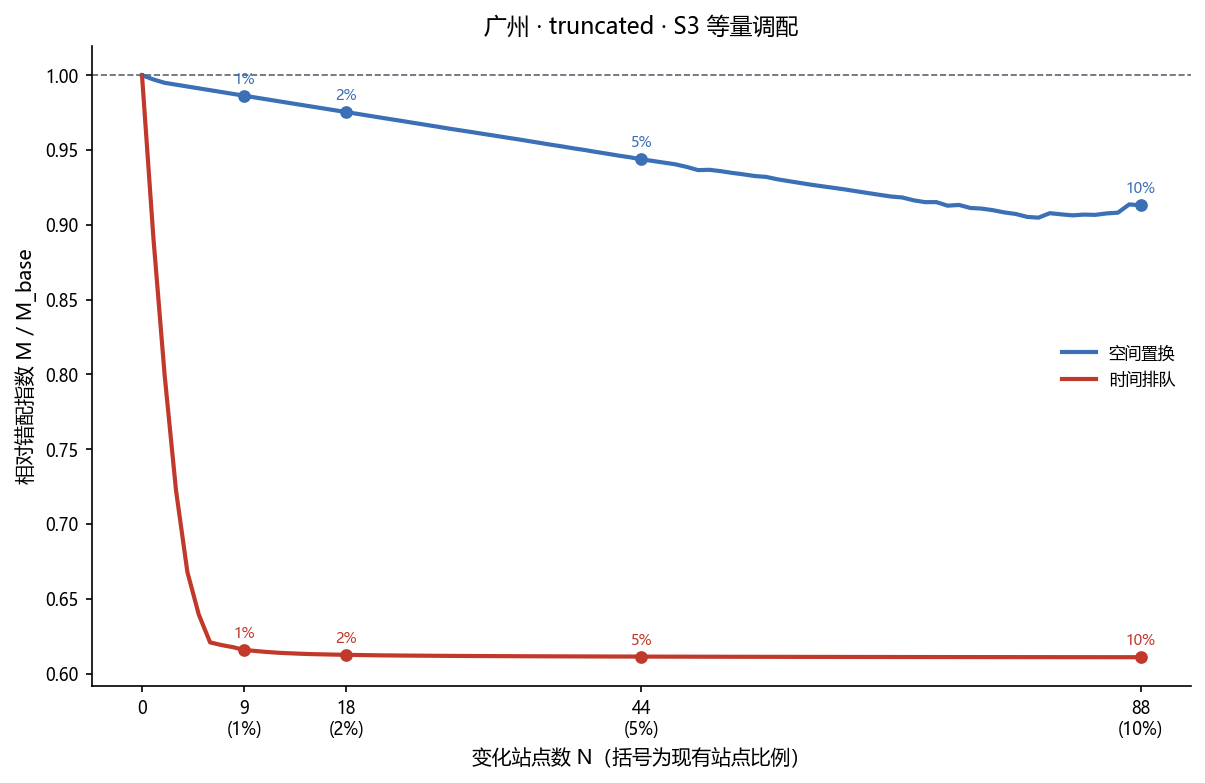

In [6]:
for scenario, title in [('s1', 'S1 只增'), ('s2', 'S2 只减'), ('s3', 'S3 等量调配')]:
    histories = {lens: pad_history(results[scenario][lens]['M'], target_len) for lens in ['disp', 'queue']}
    plot_curve(f'{cso.CITY_NAME} · {MODE} · {title}', histories)


## 3.4 三类情景地图
每个情景分别看空间置换与时间排队两种优化口径下的选址影响。


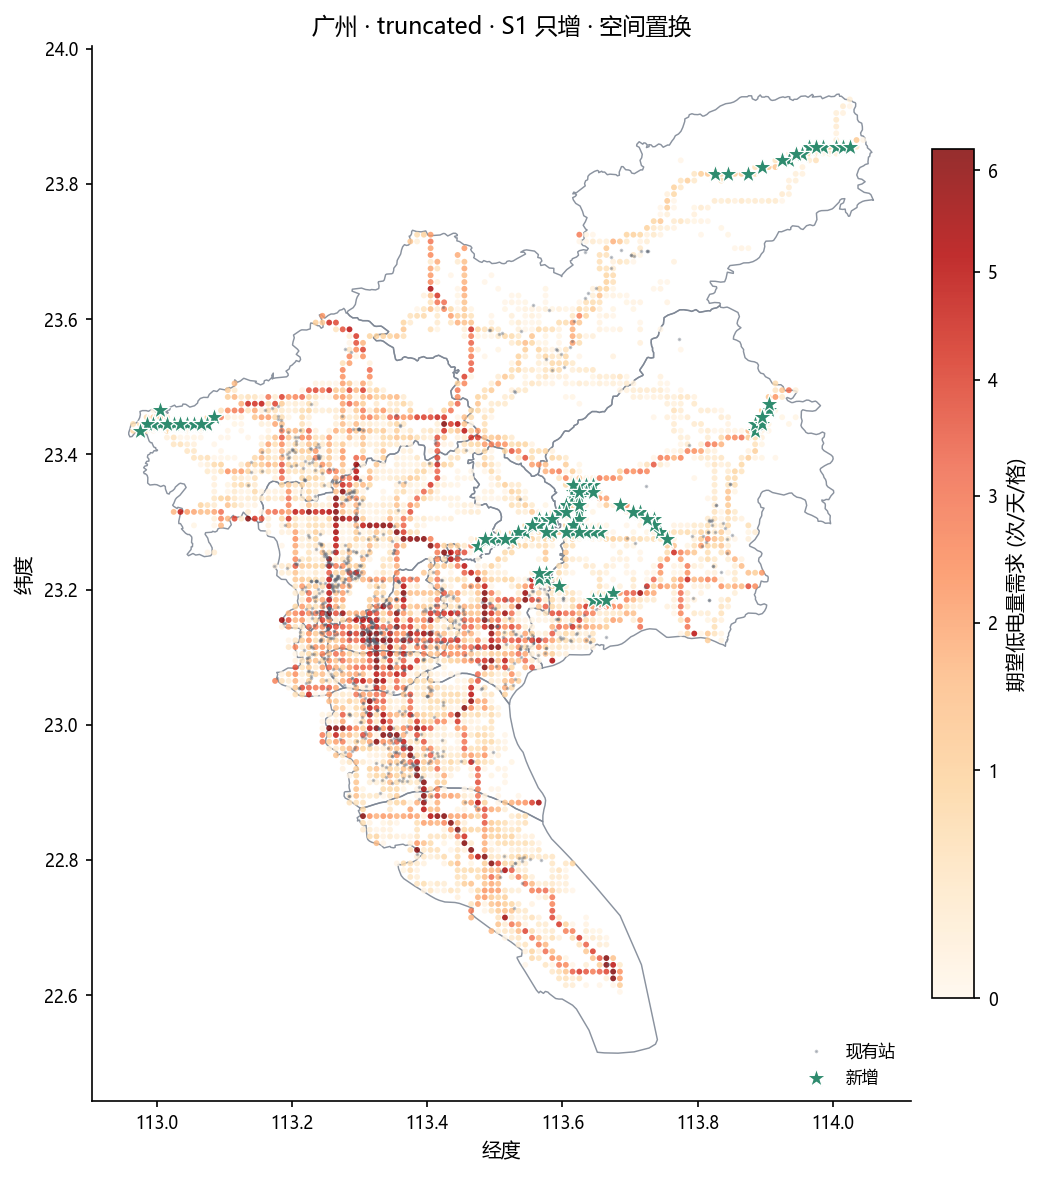

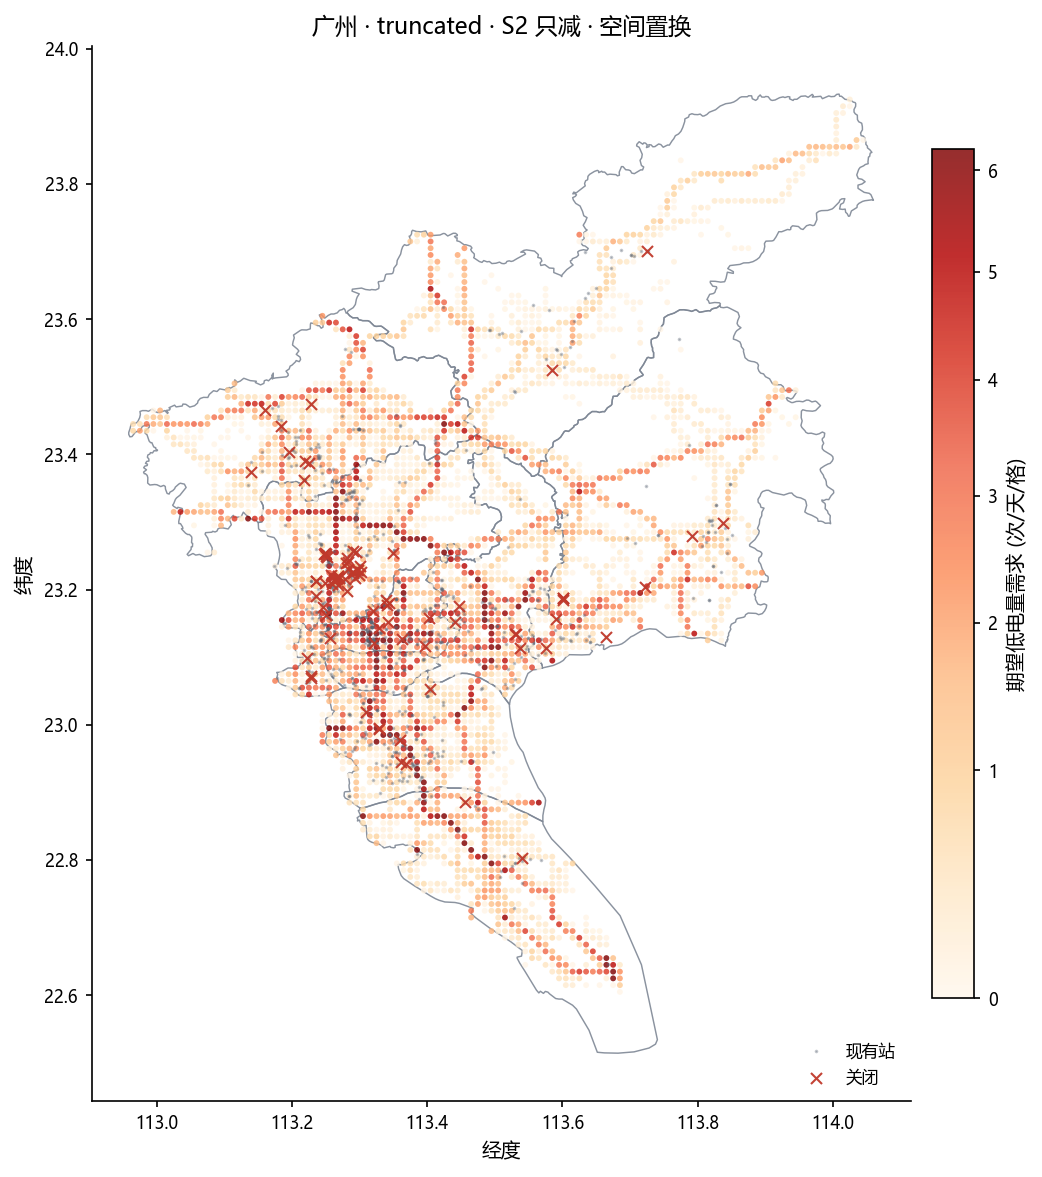

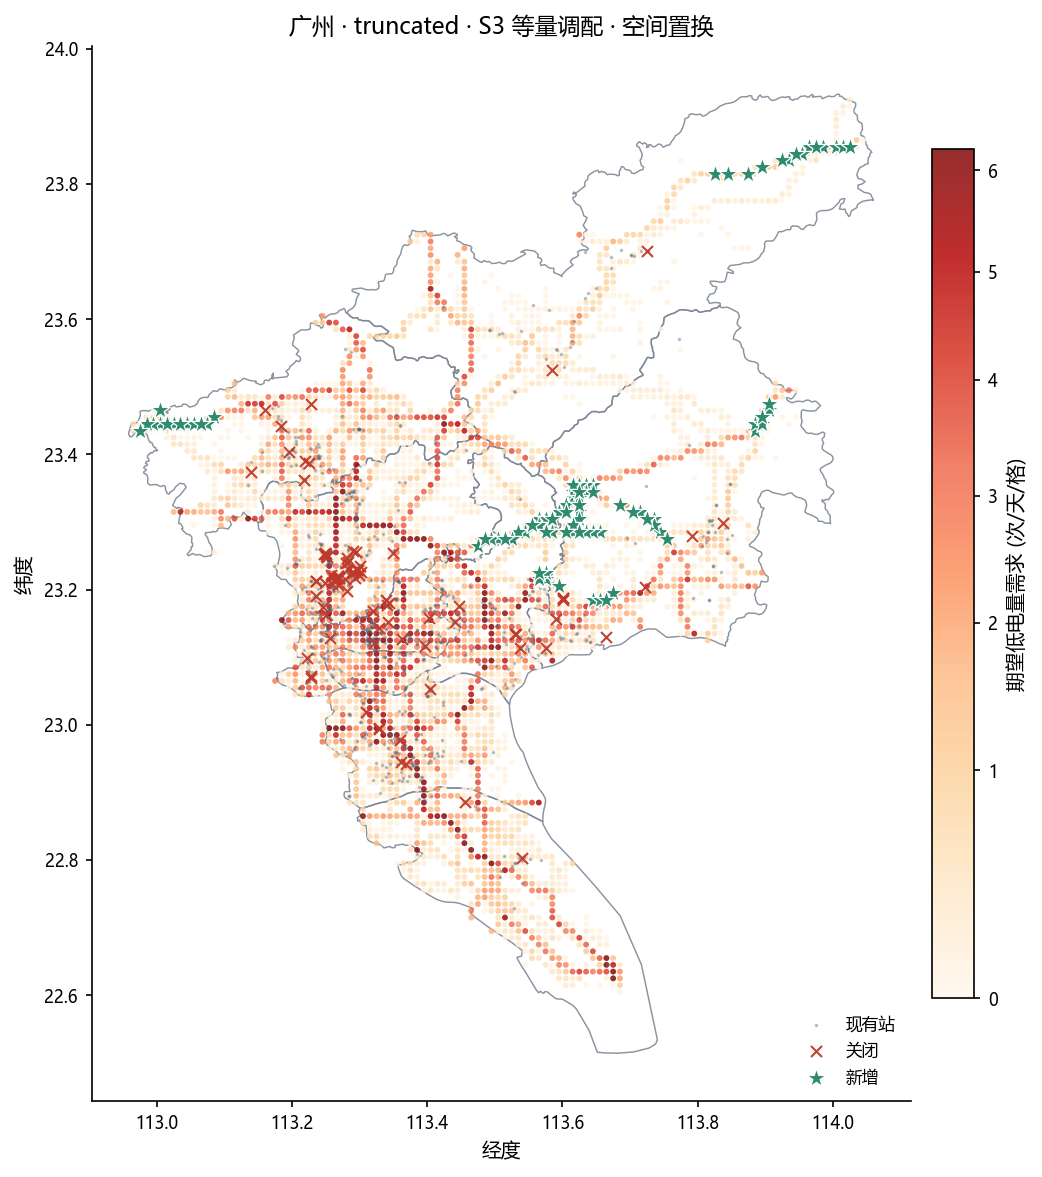

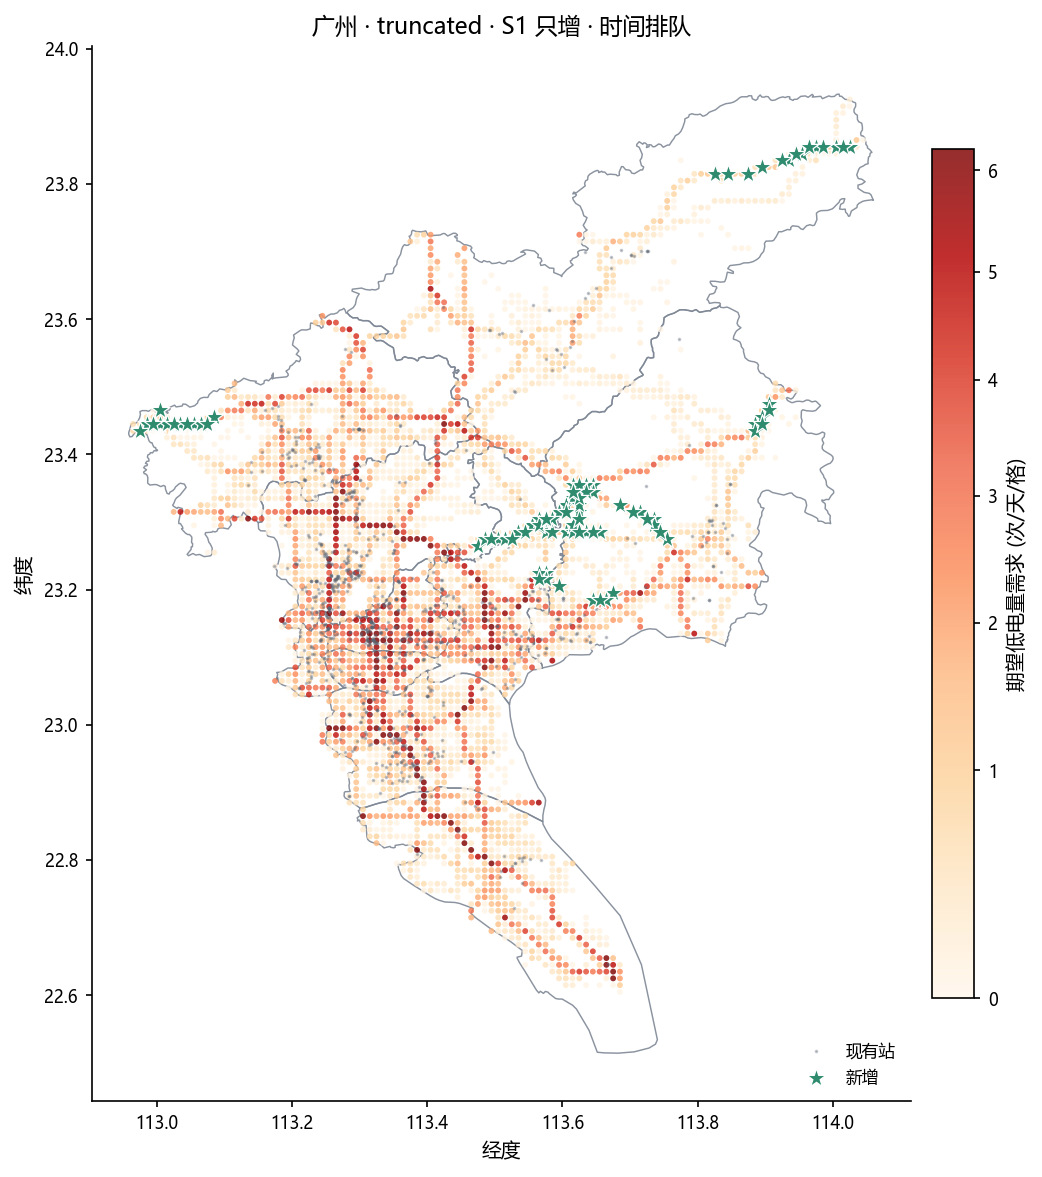

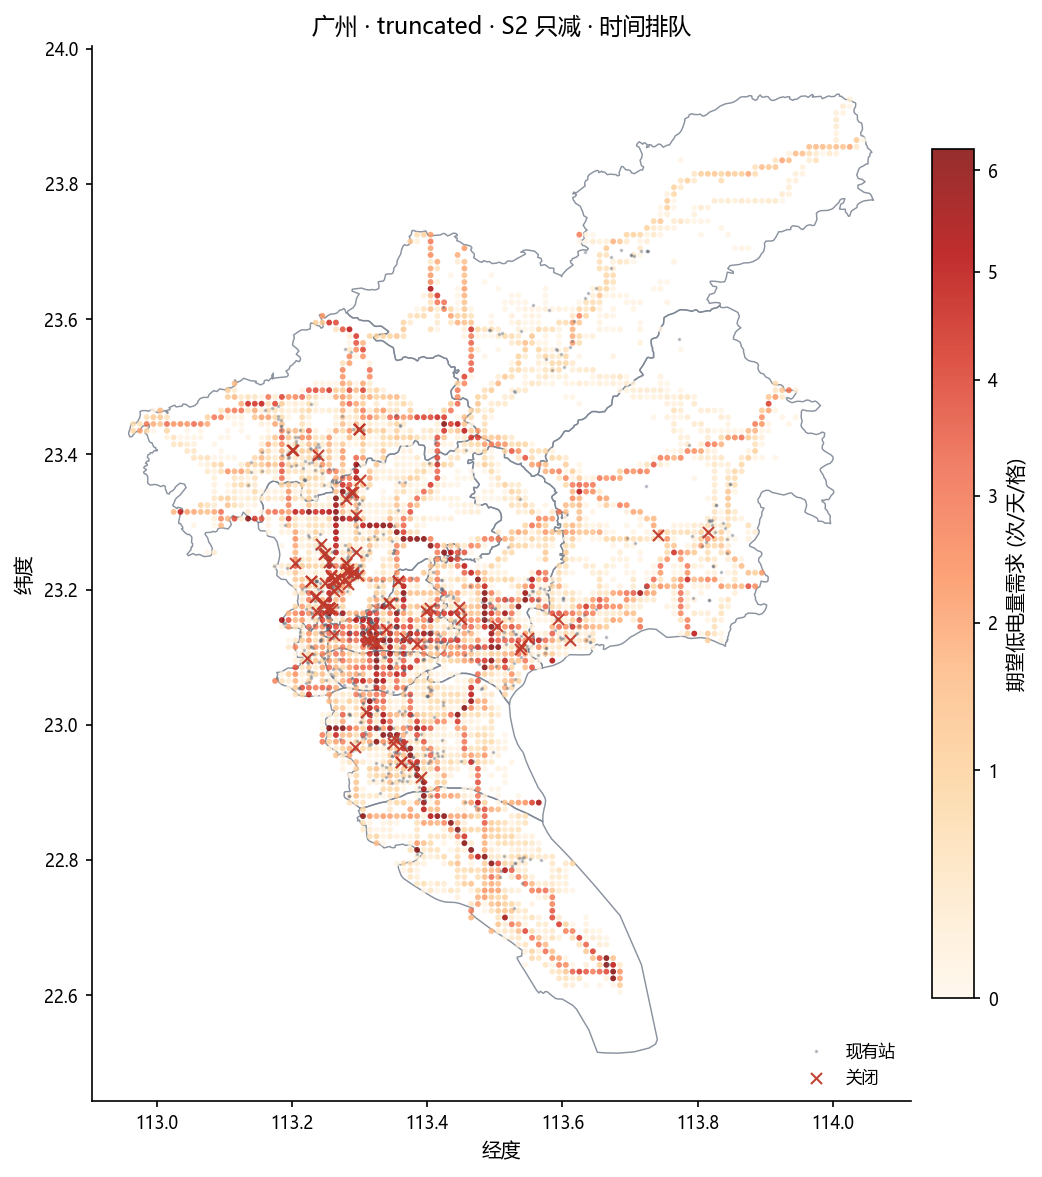

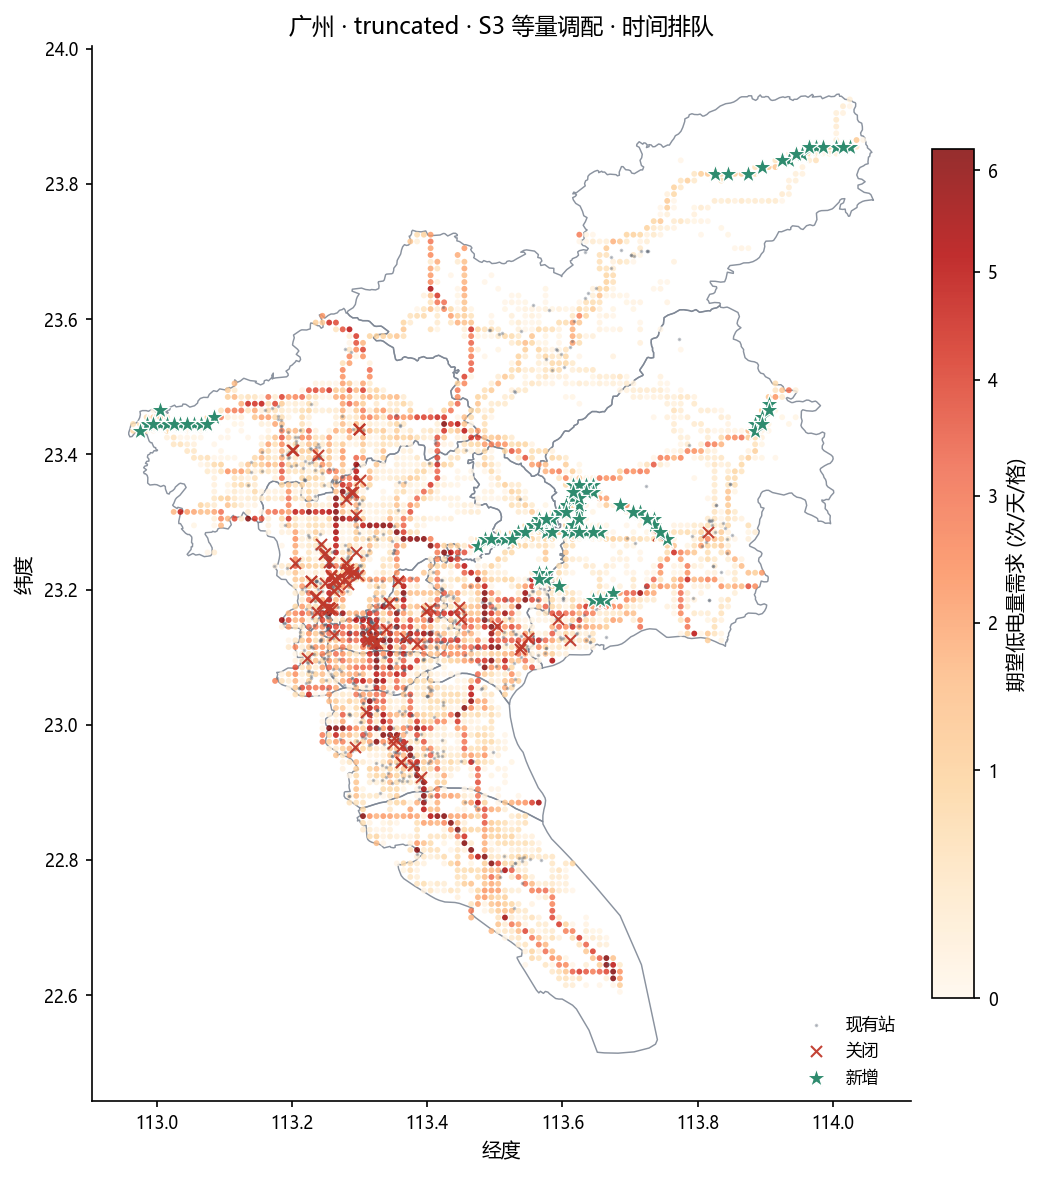

In [7]:
for lens in ['disp', 'queue']:
    name = {'disp': '空间置换', 'queue': '时间排队'}[lens]
    s1_add = cand[np.asarray(results['s1'][lens]['sel'], int)] if results['s1'][lens]['sel'] else np.array([], int)
    s2_rm = np.asarray(results['s2'][lens]['order'], int)
    s3_rm = np.asarray(results['s3'][lens]['removed'], int)
    s3_add = cand[np.asarray(results['s3'][lens]['added'], int)] if results['s3'][lens]['added'] else np.array([], int)
    plot_map(f'{cso.CITY_NAME} · {MODE} · S1 只增 · {name}', add_idx=s1_add)
    plot_map(f'{cso.CITY_NAME} · {MODE} · S2 只减 · {name}', remove_idx=s2_rm)
    plot_map(f'{cso.CITY_NAME} · {MODE} · S3 等量调配 · {name}', add_idx=s3_add, remove_idx=s3_rm)
